# AU-AIR Object Detection

## Step 1: Environment Setup

In [1]:
import sys
print(sys.executable)

/opt/anaconda3/envs/uav-det/bin/python


In [2]:
import json
import os
import random
import shutil
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Verify installs
import ultralytics
import sahi
print(f"ultralytics version : {ultralytics.__version__}")
print(f"sahi version        : {sahi.__version__}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ultralytics version : 8.4.37
sahi version        : 0.11.36


## Step 2: Dataset Exploration

In [3]:
DATA_DIR = Path("../data")
ANN_PATH = DATA_DIR / "annotations.json"
IMG_DIR  = DATA_DIR / "images"

with open(ANN_PATH) as f:
    raw = json.load(f)

CATEGORIES = raw["categories"]   # ['Human','Car','Truck','Van','Motorbike','Bicycle','Bus','Trailer']
annotations = raw["annotations"] # list of per-image dicts

print("Categories:", CATEGORIES)
print(f"Total images : {len(annotations):,}")
total_bboxes = sum(len(a["bbox"]) for a in annotations)
print(f"Total bboxes : {total_bboxes:,}")

Categories: ['Human', 'Car', 'Truck', 'Van', 'Motorbike', 'Bicycle', 'Bus', 'Trailer']
Total images : 32,823
Total bboxes : 132,031


### Image viz with Labels

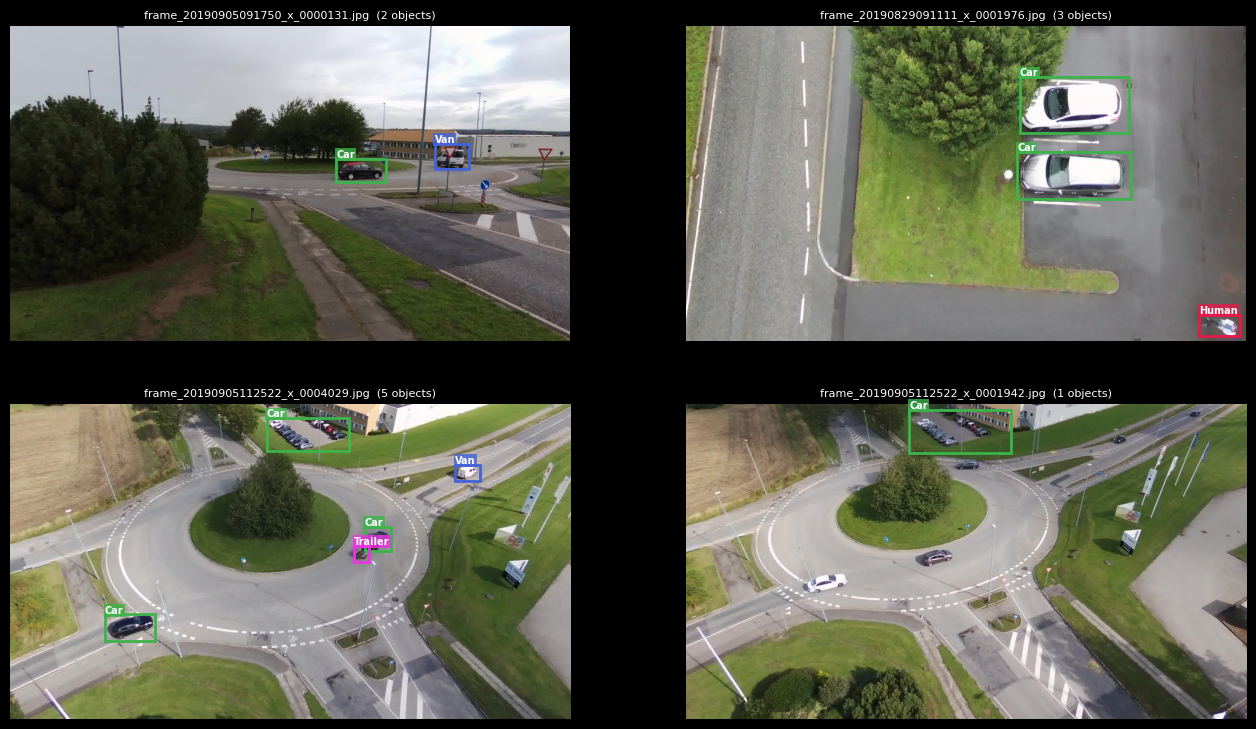

In [4]:
# Color palette (one per class)
PALETTE = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8",
    "#f58231", "#911eb4", "#42d4f4", "#f032e6"
]

def draw_bboxes(ax, image, bboxes, categories, palette):
    ax.imshow(image)
    for bbox in bboxes:
        cls   = bbox["class"]
        left  = bbox["left"]
        top   = bbox["top"]
        w     = bbox["width"]
        h     = bbox["height"]
        color = palette[cls % len(palette)]
        rect  = patches.Rectangle(
            (left, top), w, h,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            left, top - 4, categories[cls],
            color="white", fontsize=7, fontweight="bold",
            bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor="none")
        )
    ax.axis("off")

# Pick 4 representative samples and seed to ensure reproducibility
rng = random.Random(SEED)
samples = rng.sample(annotations, 4)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for ax, ann in zip(axes, samples):
    img_path = IMG_DIR / ann["image_name"]
    img = Image.open(img_path).convert("RGB")
    draw_bboxes(ax, img, ann["bbox"], CATEGORIES, PALETTE)
    n_obj = len(ann["bbox"])
    ax.set_title(f"{ann['image_name']}  ({n_obj} objects)", fontsize=8)


plt.show()

* Important details from few viz: It labeled the cars in the parking area as a whole!!

### Class Distribution

In [5]:
class_counts = Counter()
for ann in annotations:
    for bbox in ann["bbox"]:
        class_counts[bbox["class"]] += 1

# Print sorted table
print(f"{'Class':<12} {'Count':>8} {'Percent':>8}")
print("-" * 32)
for cls_id, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    pct = 100 * count / total_bboxes
    print(f"{CATEGORIES[cls_id]:<12} {count:>8,} {pct:>7.2f}%")

Class           Count  Percent
--------------------------------
Car           102,619   77.72%
Van             9,995    7.57%
Truck           9,545    7.23%
Human           5,158    3.91%
Trailer         2,538    1.92%
Bicycle         1,128    0.85%
Bus               729    0.55%
Motorbike         319    0.24%


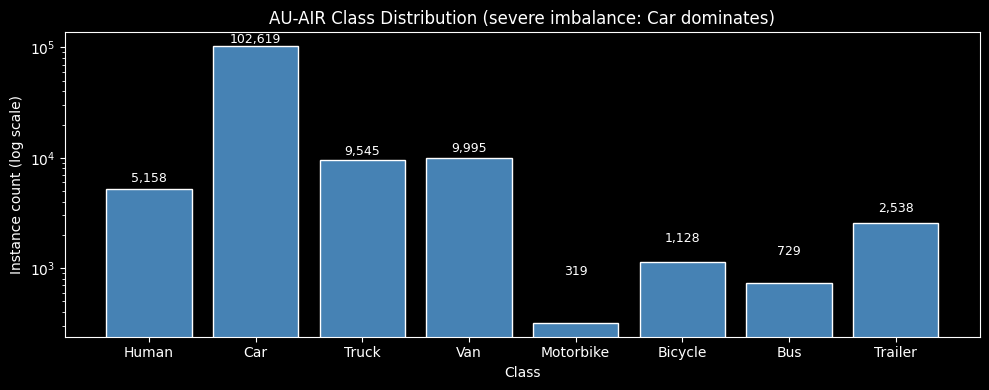

In [6]:
# Bar chart ﷿﷿﷿ class distribution
cls_ids   = sorted(class_counts.keys())
cls_names = [CATEGORIES[i] for i in cls_ids]
counts    = [class_counts[i] for i in cls_ids]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(cls_names, counts, color="steelblue", edgecolor="white")

# Annotate bars
for bar, cnt in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{cnt:,}",
        ha="center", va="bottom", fontsize=9
    )

ax.set_yscale("log")
ax.set_ylabel("Instance count (log scale)")
ax.set_title("AU-AIR Class Distribution (severe imbalance: Car dominates)")
ax.set_xlabel("Class")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

As we can see above, classes are not equally distributed, but it is normal when we deal with object detection tasks, especially from fisheye, UAV-based scene images. Because vehicles like motorbikes, buses, bicycles are really few againts to the car, trucks, etc.

### Bounding Box Size Analysis - Do we need for SAHI?

What is SAHI?

SAHI = Slicing Aided Hyper Inference

It's a technique designed for detecting "small objects" in high-resolution images. Here's the core idea: Instead of feeding the full 1920﷿﷿1080 image into the model (which gets downscaled to 640﷿﷿640, making small objects tiny or invisible), SAHI:

* Slices the full image into overlapping 640﷿﷿640 tiles
* Runs the detector on each tile independently (each tile is at full resolution)
* Merges all detections back using NMS (non-max suppression) to remove duplicates

First, we need to understand whether we need to use SAHI? Do we have really small objects in the images? When we look at the dataset, we can see objects that are far away from the camera objective; they are much smaller than the objects (vehicles) that are closer to the drone. Let's analyze it by checking available bounding boxes.

In [11]:
annotations

[{'image_name': 'frame_20190829091111_x_0001973.jpg',
  'image_width:': 1920.0,
  'image_height': 1080.0,
  'platform': 'Parrot Bebop 2',
  'time': {'year': 2019,
   'month': 8,
   'day': 29,
   'hour': 9,
   'min': 11,
   'sec': 11,
   'ms': 394400.0},
  'longtitude': 10.18798203255313,
  'latitude': 56.20630134795274,
  'altitude': 19921.6,
  'linear_x': 0.03130074199289083,
  'linear_y': 0.028357808757573367,
  'linear_z': 0.0744575835764408,
  'angle_phi': -0.06713105738162994,
  'angle_theta': 0.06894744634628296,
  'angle_psi': 1.1161083340644837,
  'bbox': [{'top': 163, 'left': 1098, 'height': 185, 'width': 420, 'class': 1},
   {'top': 421, 'left': 1128, 'height': 176, 'width': 393, 'class': 1},
   {'top': 927, 'left': 1703, 'height': 153, 'width': 183, 'class': 0}]},
 {'image_name': 'frame_20190829091111_x_0000334.jpg',
  'image_width:': 1920.0,
  'image_height': 1080.0,
  'platform': 'Parrot Bebop 2',
  'time': {'year': 2019,
   'month': 8,
   'day': 29,
   'hour': 9,
   'min'

You will see the COCO definition for in which sizes we will say it is small object, medium etc.

These threshold are directly obtained by official pycocotools evaluation code ﷿﷿﷿> cocoeval.py

https://github.com/cocodataset/cocoapi/blob/master/PythonAPI/pycocotools/cocoeval.py

In [7]:
"""class Params:
    '''
    Params for coco evaluation api
    '''
    def setDetParams(self):
        self.imgIds = []
        self.catIds = []
        # np.arange causes trouble.  the data point on arange is slightly larger than the true value
        self.iouThrs = np.linspace(.5, 0.95, int(np.round((0.95 - .5) / .05)) + 1, endpoint=True)
        self.recThrs = np.linspace(.0, 1.00, int(np.round((1.00 - .0) / .01)) + 1, endpoint=True)
        self.maxDets = [1, 10, 100]
        self.areaRng = [[0 ** 2, 1e5 ** 2], [0 ** 2, 32 ** 2], [32 ** 2, 96 ** 2], [96 ** 2, 1e5 ** 2]]
        self.areaRngLbl = ['all', 'small', 'medium', 'large']
        self.useCats = 1"""

"class Params:\n    '''\n    Params for coco evaluation api\n    '''\n    def setDetParams(self):\n        self.imgIds = []\n        self.catIds = []\n        # np.arange causes trouble.  the data point on arange is slightly larger than the true value\n        self.iouThrs = np.linspace(.5, 0.95, int(np.round((0.95 - .5) / .05)) + 1, endpoint=True)\n        self.recThrs = np.linspace(.0, 1.00, int(np.round((1.00 - .0) / .01)) + 1, endpoint=True)\n        self.maxDets = [1, 10, 100]\n        self.areaRng = [[0 ** 2, 1e5 ** 2], [0 ** 2, 32 ** 2], [32 ** 2, 96 ** 2], [96 ** 2, 1e5 ** 2]]\n        self.areaRngLbl = ['all', 'small', 'medium', 'large']\n        self.useCats = 1"

In [8]:
# Collect ALL bbox dimensions (in absolute pixels)
bbox_widths  = []
bbox_heights = []
bbox_areas   = []
# Per-class area lists for box plots
per_class_areas = defaultdict(list)

SMALL_THRESH = 32 * 32   # COCO definition: area < 32﷿﷿ px
MEDIUM_THRESH = 96 * 96  # COCO medium: 32﷿﷿ ﷿﷿﷿ 96﷿﷿

for ann in annotations:
    img_w = ann["image_width:"]   # note the typo colon in the key
    img_h = ann["image_height"]
    for bbox in ann["bbox"]:
        w = bbox["width"]
        h = bbox["height"]
        area = w * h
        bbox_widths.append(w)
        bbox_heights.append(h)
        bbox_areas.append(area)
        per_class_areas[bbox["class"]].append(area)

bbox_areas_np = np.array(bbox_areas)

n_small  = (bbox_areas_np < SMALL_THRESH).sum()
n_medium = ((bbox_areas_np >= SMALL_THRESH) & (bbox_areas_np < MEDIUM_THRESH)).sum()
n_large  = (bbox_areas_np >= MEDIUM_THRESH).sum()

print("Bounding Box Size Statistics (absolute pixels)")
print("=" * 50)
print(f"  Mean  area : {np.mean(bbox_areas_np):>10,.1f} px﷿﷿")
print(f"  Median area: {np.median(bbox_areas_np):>10,.1f} px﷿﷿")
print(f"  Min   area : {np.min(bbox_areas_np):>10,.1f} px﷿﷿")
print(f"  Max   area : {np.max(bbox_areas_np):>10,.1f} px﷿﷿")
print()
print(f"  Mean  width : {np.mean(bbox_widths):>8.1f} px")
print(f"  Mean  height: {np.mean(bbox_heights):>8.1f} px")
print()
print(f"COCO size categories (out of {total_bboxes:,} total):")
print(f"  Small  (area < 32﷿﷿)          : {n_small:>8,}  ({100*n_small/total_bboxes:.1f}%)")
print(f"  Medium (32﷿﷿ ﷿﷿﷿ area < 96﷿﷿)    : {n_medium:>8,}  ({100*n_medium/total_bboxes:.1f}%)")
print(f"  Large  (area ﷿﷿﷿ 96﷿﷿)          : {n_large:>8,}  ({100*n_large/total_bboxes:.1f}%)")

Bounding Box Size Statistics (absolute pixels)
  Mean  area :   16,478.2 px﷿﷿
  Median area:    6,624.0 px﷿﷿
  Min   area :        0.0 px﷿﷿
  Max   area : 2,046,720.0 px﷿﷿

  Mean  width :    127.5 px
  Mean  height:     85.0 px

COCO size categories (out of 132,031 total):
  Small  (area < 32﷿﷿)          :   15,574  (11.8%)
  Medium (32﷿﷿ ﷿﷿﷿ area < 96﷿﷿)    :   61,969  (46.9%)
  Large  (area ﷿﷿﷿ 96﷿﷿)          :   54,488  (41.3%)


* Look at how many bounding boxes of the classes are classified as "small"

In [7]:
# Per-class area statistics (mean and median)
print(f"{'Class':<12} {'Mean area':>12} {'Median area':>12} {'% small':>8}")
print("-" * 50)
for cls_id in sorted(per_class_areas.keys()):
    areas = np.array(per_class_areas[cls_id])
    pct_small = 100 * (areas < SMALL_THRESH).sum() / len(areas)
    print(f"{CATEGORIES[cls_id]:<12} {np.mean(areas):>12,.0f} {np.median(areas):>12,.0f} {pct_small:>7.1f}%")

Class           Mean area  Median area  % small
--------------------------------------------------
Human               7,753        4,312    14.9%
Car                13,003        5,544    13.7%
Truck              46,537       22,792     2.6%
Van                20,689       11,948     2.0%
Motorbike           8,896        4,095    11.6%
Bicycle             7,659        3,934     8.9%
Bus                47,124       34,365     2.3%
Trailer            41,159       14,824     7.1%


We're seeing more small objects in the human, motorbike, etc. We also see lots of cars in small dimension is probably caused by cars in the parking area or occlusion caused by consecutive cars.

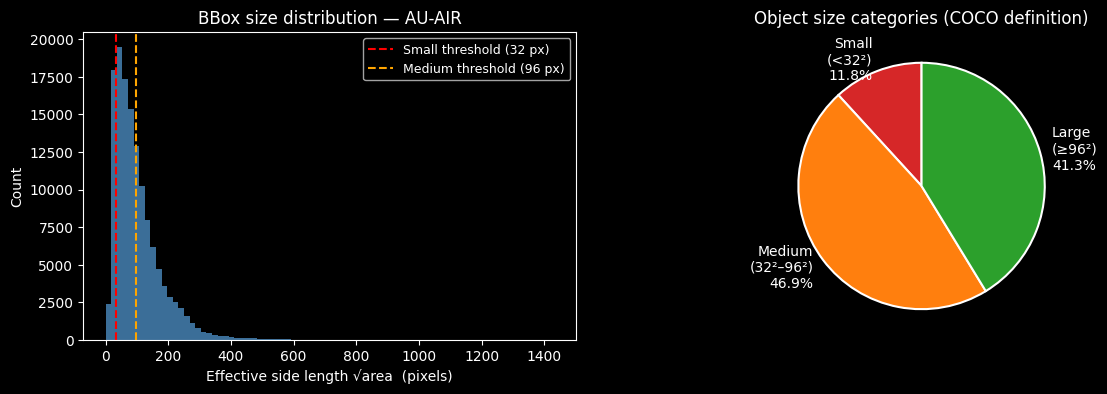

In [9]:
# Lets look at area distribution histogram + small-object threshold
# Put small-mid thresholds as well
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: histogram of sqrt(area) (effective side length)
ax = axes[0]
sqrt_areas = np.sqrt(bbox_areas_np)
ax.hist(sqrt_areas, bins=80, color="steelblue", edgecolor="none", alpha=0.85)
ax.axvline(32, color="red",    linestyle="--", linewidth=1.5, label="Small threshold (32 px)") # Put small
ax.axvline(96, color="orange", linestyle="--", linewidth=1.5, label="Medium threshold (96 px)") # Put mid
ax.set_xlabel("Effective side length ﷿﷿﷿area  (pixels)")
ax.set_ylabel("Count")
ax.set_title("BBox size distribution ﷿﷿﷿ AU-AIR")
ax.legend(fontsize=9)

# Right: pie chart ﷿﷿﷿ small / medium / large
ax = axes[1]
sizes  = [n_small, n_medium, n_large]
labels = [
    f"Small\n(<32﷿﷿)\n{100*n_small/total_bboxes:.1f}%",
    f"Medium\n(32﷿﷿﷿﷿﷿96﷿﷿)\n{100*n_medium/total_bboxes:.1f}%",
    f"Large\n(﷿﷿﷿96﷿﷿)\n{100*n_large/total_bboxes:.1f}%",
]
colors = ["#d62728", "#ff7f0e", "#2ca02c"]
ax.pie(sizes, labels=labels, colors=colors, startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Object size categories (COCO definition)")

plt.show()

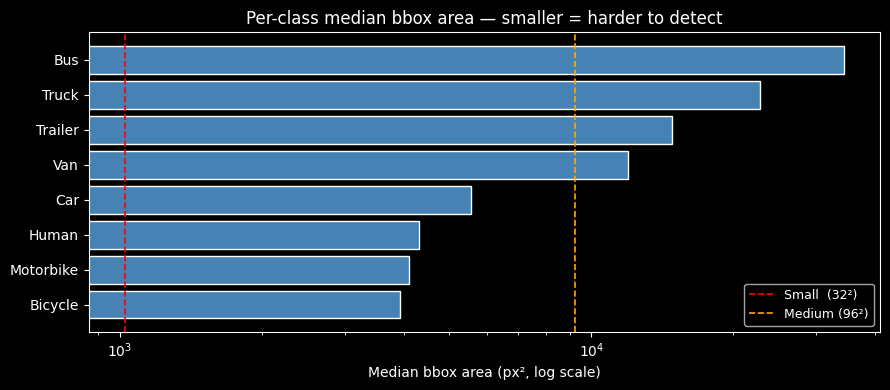

In [9]:
# Per-class median bbox area (log scale) ﷿﷿﷿ shows which classes are smallest
cls_median_areas = {
    CATEGORIES[cls_id]: np.median(areas)
    for cls_id, areas in per_class_areas.items()
}
sorted_cls = sorted(cls_median_areas, key=cls_median_areas.get)
sorted_vals = [cls_median_areas[c] for c in sorted_cls]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(sorted_cls, sorted_vals, color="steelblue", edgecolor="white")
ax.axvline(SMALL_THRESH,  color="red",    linestyle="--", linewidth=1.2, label="Small  (32﷿﷿)")
ax.axvline(MEDIUM_THRESH, color="orange", linestyle="--", linewidth=1.2, label="Medium (96﷿﷿)")
ax.set_xscale("log")
ax.set_xlabel("Median bbox area (px﷿﷿, log scale)")
ax.set_title("Per-class median bbox area ﷿﷿﷿ smaller = harder to detect")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("per_class_bbox_area.png", dpi=150)
plt.show()

### Summary & Motivation for SAHI

* **Car** accounts for ~77% of instances --> *Class imbalance is an important topic when the evaluation is made as well. Let's look at it again at the end of the task*
* **Motorbike** has only 319 instances --> *Class imbalance is an important topic when the evaluation is made as well. Let's look at it again at the end of the task*
* A significant percentages of bboxes are **small** (area < 32﷿﷿)  ---> *apprx 12%*
* Images are **1920﷿﷿1080**, when the model input is very low, heavy downscaling loses small-object detail (where we need to use SAHI)
* **SAHI** slices the full-res image into 640﷿﷿640 tiles --> Each tile keeps original resolution ﷿﷿﷿ small objects become detectable

## Step 3: Train / Val / Test Split

**Strategy: split by whole video clip not by individual frame.**

Consecutive frames in a UAV video are nearly identical (same scene, slightly shifted).
Splitting randomly by frame would cause data leakage: the model sees nearly the same
scene in both train and test, inflating accuracy. Assigning whole clips to one split
guarantees zero temporal leakage.

Target: ~85% train ﷿﷿ ~8% val ﷿﷿ ~7% test (It is same with the AU-AIR paper)

In [11]:
# Filename pattern:  frame_<timestamp>_x_<framenum>.jpg
#                    frame_<timestamp>_xx_<framenum>.jpg
# We split on "_x" and take the first part the timestamp = clip ID

def get_clip_id(image_name):
    return image_name.replace("frame_", "").split("_x")[0]

# Quick sanity check on real filenames
test_names = [
    "frame_20190829091111_x_0000156.jpg",
    "frame_20190905091750_xx_0001973.jpg",
    "frame_20190905111947_x_0000001.jpg",
]
for name in test_names:
    print(f"{name}  -->> clip: {get_clip_id(name)}")

frame_20190829091111_x_0000156.jpg  -->> clip: 20190829091111
frame_20190905091750_xx_0001973.jpg  -->> clip: 20190905091750
frame_20190905111947_x_0000001.jpg  -->> clip: 20190905111947


In [12]:
# Count frames per clip to be sure
from collections import Counter

clip_frame_counts = Counter()
for ann in annotations:
    clip_frame_counts[get_clip_id(ann["image_name"])] += 1

total_frames = sum(clip_frame_counts.values())

print(f"{'Clip ID':<20} {'Frames':>8} {'Cum. frames':>12} {'Cum. %':>8}")
print("-" * 55)
cumulative = 0
for clip_id, count in sorted(clip_frame_counts.items(), key=lambda x: -x[1]):
    cumulative += count
    print(f"{clip_id:<20} {count:>8,} {cumulative:>12,} {100*cumulative/total_frames:>7.1f}%")

Clip ID                Frames  Cum. frames   Cum. %
-------------------------------------------------------
20190906150731          6,986        6,986    21.3%
20190905103112          6,840       13,826    42.1%
20190905091750          5,734       19,560    59.6%
20190905112522          5,358       24,918    75.9%
20190905142119          2,962       27,880    84.9%
20190829091111          2,592       30,472    92.8%
20190905143505          1,580       32,052    97.7%
20190905111947            771       32,823   100.0%


In [13]:
# Assign clips to splits
# It is a manual operation

# Train: 5 largest clips 27,880 frames --> 84.9%
# Val: 1 clip  2,592 frames --> 7.9%
# Test: 2 smallest clips 2,351 frames --> 7.2%
#
# This matches the AU-AIR paper's reported apprx 30K train-val / apprx 2,823 test

CLIP_SPLIT = {
    # train
    "20190906150731": "train",
    "20190905103112": "train",
    "20190905091750": "train",
    "20190905112522": "train",
    "20190905142119": "train",
    # val
    "20190829091111": "val",
    # test
    "20190905143505": "test",
    "20190905111947": "test",
}

# Attach split label to every annotation
for ann in annotations:
    ann["split"] = CLIP_SPLIT[get_clip_id(ann["image_name"])]

# LOOK AT ANNOTATION DIST AS WELL FOR EACH DATASET TRAIN-TEST-VAL
split_frames = Counter(ann["split"] for ann in annotations)
split_bboxes = Counter()
for ann in annotations:
    split_bboxes[ann["split"]] += len(ann["bbox"])

print(f"{'Split':<8} {'Frames':>8} {'Frames %':>10} {'BBoxes':>10} {'BBoxes %':>10}")
print("-" * 52)
for split in ["train", "val", "test"]:
    f  = split_frames[split]
    b  = split_bboxes[split]
    fp = 100 * f / total_frames
    bp = 100 * b / total_bboxes
    print(f"{split:<8} {f:>8,} {fp:>9.1f}% {b:>10,} {bp:>9.1f}%")
print("-" * 52)
print(f"{'TOTAL':<8} {total_frames:>8,} {'100.0%':>10} {total_bboxes:>10,} {'100.0%':>10}")

Split      Frames   Frames %     BBoxes   BBoxes %
----------------------------------------------------
train      27,880      84.9%    114,282      86.6%
val         2,592       7.9%      6,300       4.8%
test        2,351       7.2%     11,449       8.7%
----------------------------------------------------
TOTAL      32,823     100.0%    132,031     100.0%
